In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/banknote_authentication.csv"
columns = ['variance', 'skewness', 'curtosis', 'entropy', 'class']

df = pd.read_csv(url, names=columns)

x = df.drop(columns=['class'])
y = df['class']

print(x.head())
print(y.head())

   variance  skewness  curtosis  entropy
0   3.62160    8.6661   -2.8073 -0.44699
1   4.54590    8.1674   -2.4586 -1.46210
2   3.86600   -2.6383    1.9242  0.10645
3   3.45660    9.5228   -4.0112 -3.59440
4   0.32924   -4.4552    4.5718 -0.98880
0    0
1    0
2    0
3    0
4    0
Name: class, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [7]:
from sklearn.svm import SVC
model=SVC()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("accuracy=",accuracy_score(y_test,y_pred))
print("classification report=\n",classification_report(y_test,y_pred))
print("confusion matrix=\n",confusion_matrix(y_test,y_pred))

print("Training Accuracy:", accuracy_score(y_train, model.predict(x_train)))
print("Testing Accuracy:", accuracy_score(y_test, y_pred))

accuracy= 1.0
classification report=
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       148
           1       1.00      1.00      1.00       127

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275

confusion matrix=
 [[148   0]
 [  0 127]]
Training Accuracy: 1.0
Testing Accuracy: 1.0


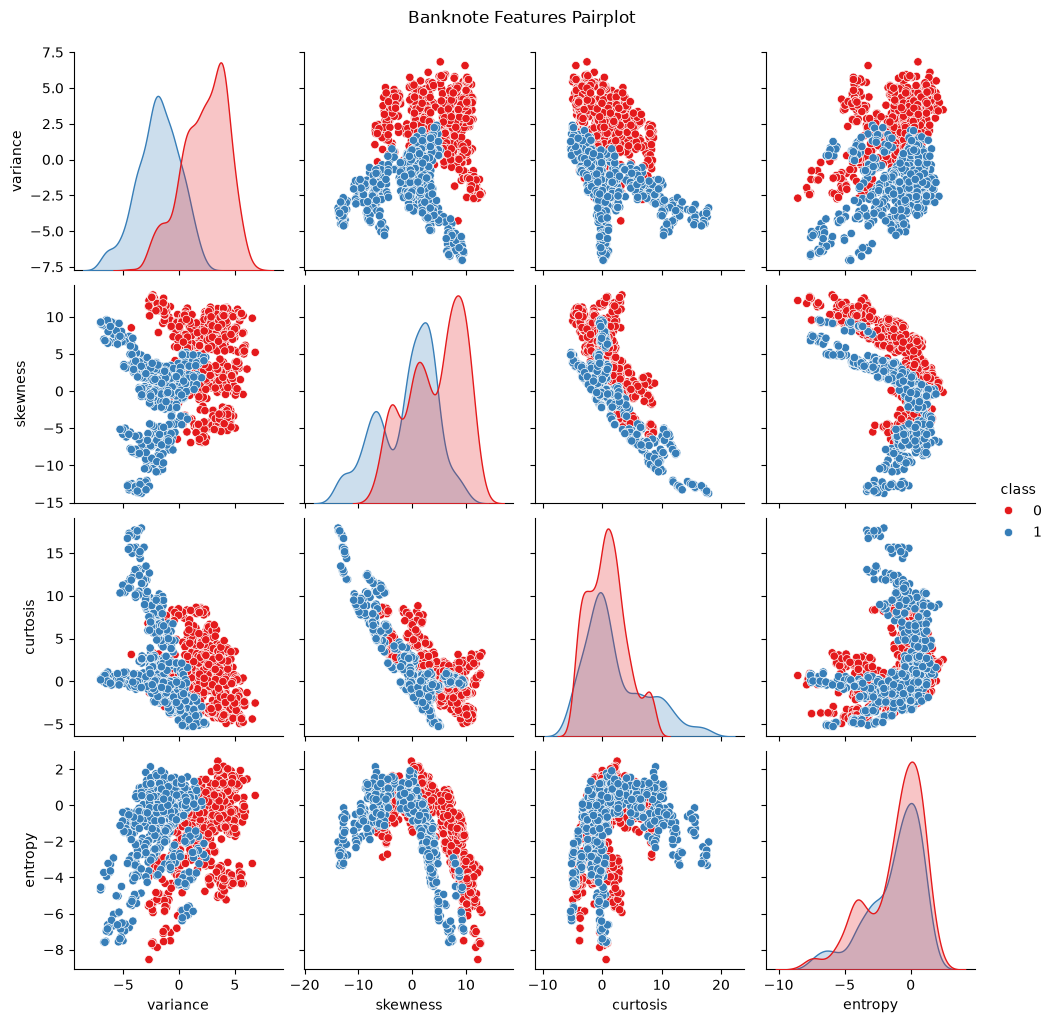

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(df, hue='class', palette='Set1', diag_kind='kde')
plt.suptitle('Banknote Features Pairplot', y=1.02)
plt.show()